# 252. Deep-twilight controls: how far back does each tool carry a functional label?

Three families of homologs whose function has been studied by experiment: the globins,
lysozyme with alpha-lactalbumin, and the cystatins. Within each family, every protein is
searched against every other, and each tool is asked one question per pair: does it place
the query's functional residues on the target's? The pairs run from 12.5% to 84.4% global
identity, so the figure shows where each tool stops carrying the label.

This is a control, not the hero example. All 16 proteins have confident AlphaFold models
(mean pLDDT 88 to 98), so structure search should do well here.

Tools, all searching the same database (the 20_600-protein QfO human proteome with the 8
non-human family members added) and all cut at $E \le 1000$:

* kmerseek, every alphabet and k of the nb 241 ladder (151 of its 152 combinations; gbmr7
  at k=8 was killed for memory at 96 GB while its index fitted the Karlin-Altschul
  constants), with ungapped extension; kmerseek branch `olgabot/run-evalue` at 5fdfdcc, where every region has a
  `region_evalue`
* phmmer (HMMER 3.4), `--max`
* MMseqs2 18.8cc5c, sensitivity `-s 7.5`, `--exhaustive-search 1`
* Foldseek 10.941cd33 on AlphaFold DB v6 models, `--exhaustive-search 1`

Pipeline: `nextflow-runs/deep-twilight-controls` (run on Sherlock). Labels:
`tables/deep_twilight_pairs.tsv`, written by `scripts/make_deep_twilight_pairs_tsv.py`.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import polars as pl

sys.path.insert(0, str(Path.cwd()))
import deep_twilight_utils as du

pl.Config.set_tbl_rows(200)
pl.Config.set_tbl_width_chars(220)
pl.Config.set_fmt_str_lengths(80)
FIG = Path("../figures")
R = du.RESULTS
if not (R / "outcomes.parquet").exists():
    raise SystemExit(f"No results at {R}: run `make pull-results` in nextflow-runs/deep-twilight-controls")

labels = du.load_labels()
arms = du.load_arms()
seqs = du.read_fasta()
outcomes = pl.read_parquet(R / "outcomes.parquet")
calls = pl.read_parquet(R / "calls.parquet")
pair_kmers = pl.read_parquet(R / "pair_kmers.parquet")
names = dict(zip(labels["accession"], labels["common_name"]))
ran = outcomes.filter(pl.col("tool") == "kmerseek").select("alphabet", "ksize").unique()
print("alphabet-k combinations without results (not drawn):",
      arms.join(ran, on=["alphabet", "ksize"], how="anti").select("alphabet", "ksize").rows())
arms = arms.join(ran, on=["alphabet", "ksize"], how="semi")
print(labels.select("family", "accession", "common_name", "label", "positions", "residues", "evidence_codes"))
print(f"{outcomes.select('query', 'target').unique().height} ordered pairs, "
      f"{outcomes.select('tool', 'alphabet', 'ksize').unique().height} tools or kmerseek alphabet-k combinations")

alphabet-k combinations without results (not drawn): [('gbmr7', 8)]
shape: (20, 7)
┌──────────────────────┬───────────┬─────────────────────────────────┬───────────────────────────┬──────────────────────────────────┬───────────┬─────────────────────────────────────┐
│ family               ┆ accession ┆ common_name                     ┆ label                     ┆ positions                        ┆ residues  ┆ evidence_codes                      │
│ ---                  ┆ ---       ┆ ---                             ┆ ---                       ┆ ---                              ┆ ---       ┆ ---                                 │
│ str                  ┆ str       ┆ str                             ┆ str                       ┆ str                              ┆ str       ┆ str                                 │
╞══════════════════════╪═══════════╪═════════════════════════════════╪═══════════════════════════╪══════════════════════════════════╪═══════════╪════════════════════════════════════

## 1. The families and the label each tool has to carry

Positions are 1-based on the full UniProt sequence, signal peptide included, and come from
each entry's own Swiss-Prot features:

* Globins: the histidine bound to the heme iron. Swiss-Prot calls it the "proximal
  binding residue", or the "axial binding residue" in the midge and bloodworm globins (the
  midge entry lists two).
* Lysozymes: the two catalytic residues (Active site).
* Alpha-lactalbumins: the calcium-binding residues. The lysozymes have none, and the
  alpha-lactalbumins have no catalytic residues, so a lysozyme-to-lactalbumin pair asks
  whether the tool leaves the other protein's label off.
* Cystatins: the reactive site (one glycine near the N-terminus) and the "secondary area
  of contact" (the QxVxG motif), scored as two separate labels.

References for the families:

Lesk, Arthur M., and Cyrus Chothia. "How Different Amino Acid Sequences Determine Similar
Protein Structures: The Structure and Evolutionary Dynamics of the Globins." *Journal of
Molecular Biology* 136, no. 3 (1980): 225–70. https://doi.org/10.1016/0022-2836(80)90373-3

Appleby, C. A. "Leghemoglobin and Rhizobium Respiration." *Annual Review of Plant
Physiology* 35, no. 1 (1984): 443–78. https://doi.org/10.1146/annurev.pp.35.060184.002303

Brew, Keith, Thomas C. Vanaman, and Robert L. Hill. "Comparison of the Amino Acid Sequence
of Bovine α-Lactalbumin and Hens Egg White Lysozyme." *Journal of Biological Chemistry*
242, no. 16 (1967): 3747–48. https://doi.org/10.1016/s0021-9258(18)95873-4

Rawlings, Neil D., and Alan J. Barrett. "Evolution of Proteins of the Cystatin
Superfamily." *Journal of Molecular Evolution* 30, no. 1 (1990): 60–71.
https://doi.org/10.1007/bf02102453

Bode, W., R. Engh, D. Musil, U. Thiele, R. Huber, A. Karshikov, J. Brzin, J. Kos, and
V. Turk. "The 2.0 Å X-Ray Crystal Structure of Chicken Egg White Cystatin and Its Possible
Mode of Interaction with Cysteine Proteinases." *The EMBO Journal* 7, no. 8 (1988):
2593–99. https://doi.org/10.1002/j.1460-2075.1988.tb03109.x

**Note:** each DOI above was read from Crossref and resolves at doi.org (checked
2026-09-25).

## 2. How a transfer is scored

A call is one aligned region from one tool: a kmerseek region (ungapped), a phmmer domain,
or an MMseqs2 or Foldseek alignment. Only calls with $E \le 1000$ count. For kmerseek that
is `region_evalue`, the number of regions at least this good an unrelated query would find
in the whole database.

For one query, one target and one label, let $Q$ be the query's labelled residues and $T$
the target's. The outcome is:

| outcome | when |
|---|---|
| correct | a call aligns a residue of $Q$ to a residue of $T$ |
| misplaced | calls align residues of $Q$ to the target, none of them to $T$ |
| no call | no call aligns any residue of $Q$ |
| carried wrongly | $T$ is empty and a call aligns a residue of $Q$ to the target anyway |
| not carried | $T$ is empty, the tool has a call on this pair, and none aligns a residue of $Q$ |

A pair on which the tool has no call at all is "no call", whether or not the target has
the label.

The x-axis is the global identity of the pair from EMBOSS `needle` (BLOSUM62, gap open 10,
gap extend 0.5):

$$
\text{identity} = \frac{n_\text{identical}}{n_\text{alignment columns}} \times 100
$$

where $n_\text{alignment columns}$ counts gaps too.

For a kmerseek call of length $\ell_\text{call}$ that covers a labelled query residue,
slide the same window to every start position on a target of length $n_\text{target}$.
The share of positions at which a residue of $Q$ lands on a residue of $T$ is

$$
\Pr(\text{correct by placement}) =
\frac{\#\{\text{start positions where a residue of } Q \text{ lands on } T\}}
{n_\text{target} - \ell_\text{call} + 1}
$$

This is how often the call would be right if only its length were real and its placement
were chance.

## 3. Which tool carries the label, as a function of identity

One square per query, target and label; pairs sorted by global identity, lowest on the
left. Each family has its own columns.

baselines, outcome counts per family:
shape: (9, 6)
┌──────────────────────┬──────────┬─────────────────┬─────────┬───────────┬─────────┐
│ family               ┆ tool     ┆ carried wrongly ┆ correct ┆ misplaced ┆ no call │
│ ---                  ┆ ---      ┆ ---             ┆ ---     ┆ ---       ┆ ---     │
│ str                  ┆ str      ┆ u32             ┆ u32     ┆ u32       ┆ u32     │
╞══════════════════════╪══════════╪═════════════════╪═════════╪═══════════╪═════════╡
│ cystatin             ┆ foldseek ┆ 0               ┆ 24      ┆ 0         ┆ 0       │
│ cystatin             ┆ mmseqs2  ┆ 0               ┆ 13      ┆ 0         ┆ 11      │
│ cystatin             ┆ phmmer   ┆ 0               ┆ 18      ┆ 0         ┆ 6       │
│ globin               ┆ foldseek ┆ 0               ┆ 56      ┆ 0         ┆ 0       │
│ globin               ┆ mmseqs2  ┆ 0               ┆ 15      ┆ 2         ┆ 39      │
│ globin               ┆ phmmer   ┆ 0               ┆ 45      ┆ 1         ┆ 10      │
│ 

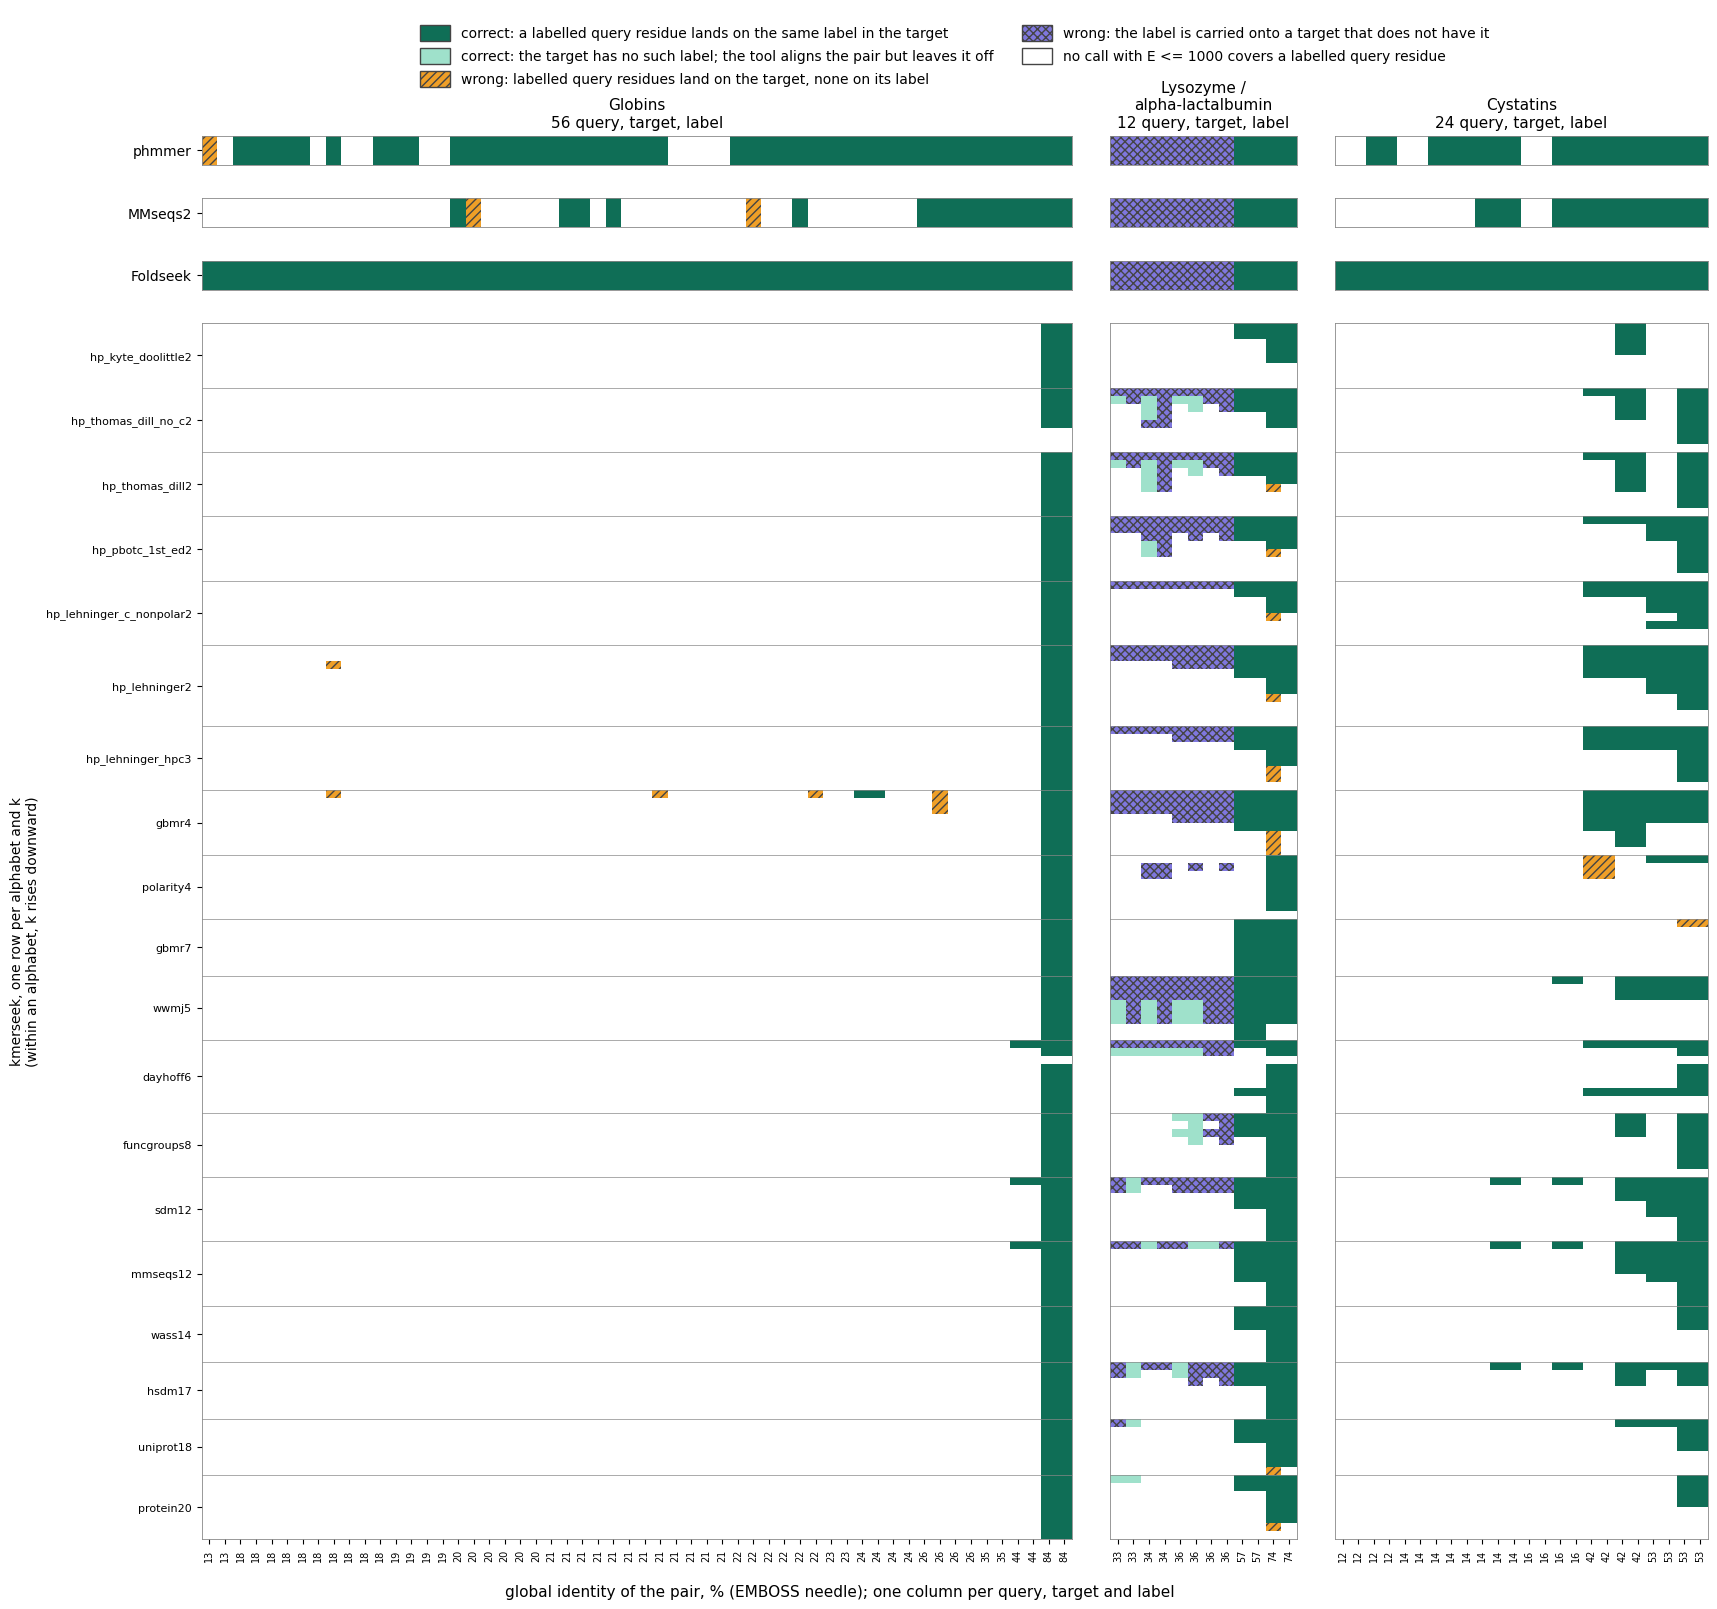

In [2]:
fig, axes = du.draw_heatmap(outcomes, arms)
fig.savefig(FIG / "252_deep_twilight_label_transfer.png", dpi=200, bbox_inches="tight")

# the numbers behind the figure: outcome counts per family and tool
km_any = (
    outcomes.filter(pl.col("tool") == "kmerseek")
    .group_by("family", "query", "target", "label")
    .agg(
        (pl.col("outcome").is_in(["correct", "not carried"])).sum().alias("n_arms_right"),
        (pl.col("outcome").is_in(["misplaced", "carried wrongly"])).sum().alias("n_arms_wrong"),
    )
)
counts = (
    outcomes.filter(pl.col("tool") != "kmerseek")
    .group_by("family", "tool", "outcome").len()
    .pivot(on="outcome", index=["family", "tool"], values="len")
    .fill_null(0)
    .sort("family", "tool")
)
print("baselines, outcome counts per family:")
print(counts)
print("kmerseek, outcome counts over all 151 alphabet-k combinations:")
print(outcomes.filter(pl.col("tool") == "kmerseek").group_by("family", "outcome").len()
      .pivot(on="outcome", index="family", values="len").fill_null(0))

### Lowest identity at which each tool still places the label correctly

For kmerseek two rows: the single alphabet and k that is right at the lowest identity
(chosen after seeing the results, so it is an upper bound), and the share of the 151
combinations that are right on each pair.

In [3]:
right = outcomes.filter((pl.col("outcome") == "correct"))
lowest = (
    right.filter(pl.col("tool") != "kmerseek")
    .group_by("family", "tool").agg(pl.col("needle_identity_pct").min().alias("lowest_identity_correct_pct"),
                                    pl.len().alias("n_correct"))
)
km_best = (
    right.filter(pl.col("tool") == "kmerseek")
    .group_by("family").agg(pl.col("needle_identity_pct").min().alias("lowest_identity_correct_pct"))
    .with_columns(tool=pl.lit("kmerseek, best of 151"))
)
n_with_label = outcomes.filter(pl.col("target_has_label")).select("family", "query", "target", "label").unique().group_by("family").len().rename({"len": "n_label_pairs"})
print(pl.concat([lowest.drop("n_correct"), km_best.select(lowest.drop("n_correct").columns)])
      .join(n_with_label, on="family").sort("family", "lowest_identity_correct_pct"))

share = (
    outcomes.filter((pl.col("tool") == "kmerseek") & pl.col("target_has_label"))
    .group_by("family", "query", "target", "label", "needle_identity_pct")
    .agg((pl.col("outcome") == "correct").mean().alias("share_of_151_correct"))
    .sort("family", "needle_identity_pct")
)
print(share.with_columns(query_name=pl.col("query").replace_strict(names), target_name=pl.col("target").replace_strict(names))
      .select("family", "needle_identity_pct", "query_name", "target_name", "label", "share_of_151_correct"))

shape: (12, 4)
┌──────────────────────┬───────────────────────┬─────────────────────────────┬───────────────┐
│ family               ┆ tool                  ┆ lowest_identity_correct_pct ┆ n_label_pairs │
│ ---                  ┆ ---                   ┆ ---                         ┆ ---           │
│ str                  ┆ str                   ┆ f64                         ┆ u32           │
╞══════════════════════╪═══════════════════════╪═════════════════════════════╪═══════════════╡
│ cystatin             ┆ foldseek              ┆ 12.5                        ┆ 24            │
│ cystatin             ┆ phmmer                ┆ 12.5                        ┆ 24            │
│ cystatin             ┆ mmseqs2               ┆ 14.0                        ┆ 24            │
│ cystatin             ┆ kmerseek, best of 151 ┆ 14.0                        ┆ 24            │
│ globin               ┆ foldseek              ┆ 12.7                        ┆ 56            │
│ globin               ┆ phmmer    

## 4. kmerseek: which regions were extended, where the E-value came from, and the placement check

An alphabet-k combination whose index could not fit the Karlin-Altschul constants was
searched without extension; its `region_evalue` is then `region_run_evalue`.
`region_ka_evalue` is left empty where the pair has no positive $\lambda$ (Karlin-Altschul
scale), never filled with a number.

In [4]:
km_calls = calls.filter(pl.col("tool") == "kmerseek")
print(arms.join(km_calls.group_by("alphabet", "ksize").agg(pl.col("extended").first()),
                on=["alphabet", "ksize"], how="left")
      .group_by("extended").len())
print(km_calls.group_by("evalue_source").agg(pl.len(), pl.col("ka_evalue").null_count().alias("ka_evalue_empty")))

placed = outcomes.filter((pl.col("tool") == "kmerseek") & (pl.col("outcome") == "correct"))
print("placement check on kmerseek's correct calls:")
print(placed.group_by("family", "label").agg(
    pl.len().alias("n_correct_calls"),
    pl.col("placement_null").median().alias("median_Pr_correct_by_placement"),
    pl.col("placement_null").max().alias("max_Pr_correct_by_placement"),
).sort("family", "label"))

shape: (3, 2)
┌──────────┬─────┐
│ extended ┆ len │
│ ---      ┆ --- │
│ bool     ┆ u32 │
╞══════════╪═════╡
│ true     ┆ 66  │
│ false    ┆ 84  │
│ null     ┆ 1   │
└──────────┴─────┘
shape: (2, 3)
┌───────────────┬──────┬─────────────────┐
│ evalue_source ┆ len  ┆ ka_evalue_empty │
│ ---           ┆ ---  ┆ ---             │
│ str           ┆ u32  ┆ u32             │
╞═══════════════╪══════╪═════════════════╡
│ run           ┆ 2752 ┆ 2752            │
│ ka            ┆ 2904 ┆ 0               │
└───────────────┴──────┴─────────────────┘
placement check on kmerseek's correct calls:
shape: (5, 5)
┌──────────────────────┬───────────────────────────┬─────────────────┬────────────────────────────────┬─────────────────────────────┐
│ family               ┆ label                     ┆ n_correct_calls ┆ median_Pr_correct_by_placement ┆ max_Pr_correct_by_placement │
│ ---                  ┆ ---                       ┆ ---             ┆ ---                            ┆ ---                       

## 5. Shared k-mers and the longest identical-class run, per pair

From `kmerseek pair`, which needs no database. `n_shared_kmers` counts k-mers present in
both encoded sequences. `longest_identical_class_run` is the longest stretch, on any
ungapped diagonal, where the two proteins are in the same class at every position; it does
not depend on k. Shown for `hp_pbotc_1st_ed2`, the alphabet printed under the residues
below.

In [5]:
fam = dict(zip(labels["accession"], labels["family"]))
ident = outcomes.select("query", "target", "needle_identity_pct").unique()
pk = (pair_kmers.filter(pl.col("alphabet") == "hp_pbotc_1st_ed2")
      .join(ident, on=["query", "target"])
      .with_columns(family=pl.col("query").replace_strict(fam))
      .pivot(on="ksize", index=["family", "query", "target", "needle_identity_pct", "longest_identical_class_run"],
             values="n_shared_kmers")
      .sort("family", "needle_identity_pct"))
print("hp_pbotc_1st_ed2: shared k-mers at each k (columns), and the longest identical-class run")
print(pk)

hp_pbotc_1st_ed2: shared k-mers at each k (columns), and the longest identical-class run
shape: (80, 13)
┌──────────────────────┬────────┬────────┬─────────────────────┬───┬─────┬─────┬─────┬─────┐
│ family               ┆ query  ┆ target ┆ needle_identity_pct ┆ … ┆ 32  ┆ 36  ┆ 40  ┆ 44  │
│ ---                  ┆ ---    ┆ ---    ┆ ---                 ┆   ┆ --- ┆ --- ┆ --- ┆ --- │
│ str                  ┆ str    ┆ str    ┆ f64                 ┆   ┆ i64 ┆ i64 ┆ i64 ┆ i64 │
╞══════════════════════╪════════╪════════╪═════════════════════╪═══╪═════╪═════╪═════╪═════╡
│ cystatin             ┆ P01038 ┆ P01040 ┆ 12.5                ┆ … ┆ 0   ┆ 0   ┆ 0   ┆ 0   │
│ cystatin             ┆ P01040 ┆ P01038 ┆ 12.5                ┆ … ┆ 0   ┆ 0   ┆ 0   ┆ 0   │
│ cystatin             ┆ P04080 ┆ P01038 ┆ 13.5                ┆ … ┆ 0   ┆ 0   ┆ 0   ┆ 0   │
│ cystatin             ┆ P01038 ┆ P04080 ┆ 13.5                ┆ … ┆ 0   ┆ 0   ┆ 0   ┆ 0   │
│ cystatin             ┆ P01034 ┆ P01040 ┆ 14.0           

## 6. The aligned residues of every label, pair by pair

For each pair and label: every baseline call that covers a labelled query residue, and the
kmerseek call with the lowest E-value among the alphabet-k combinations that placed it
correctly (or, when none did, among those that covered it). `*` marks a labelled residue
on the protein above or below it; `|` marks an identical residue, or an identical class in
the class block. The class strings are `hp_pbotc_1st_ed2`: H for ACFILMPVWY (hydrophobic),
P for DEGHKNQRST (polar). Coordinates are 1-based on the full UniProt sequence.

In [6]:
lab_pos = {(r["accession"], r["label"]): {int(p) for p in r["positions"].split(",")} for r in labels.iter_rows(named=True)}
call_by_id = {r["call_id"]: r for r in calls.iter_rows(named=True)}
order = ["phmmer", "mmseqs2", "foldseek", "kmerseek"]
for family in du.FAMILIES:
    print("=" * 100)
    print(du.FAMILY_TITLE[family])
    cols = du.pair_order(outcomes, family)
    for c in cols.iter_rows(named=True):
        q, t, lab = c["query"], c["target"], c["label"]
        print("-" * 100)
        print(f"{names[q]} ({q}) -> {names[t]} ({t}); {lab}; global identity {c['needle_identity_pct']:.1f}%")
        sub = outcomes.filter((pl.col("query") == q) & (pl.col("target") == t) & (pl.col("label") == lab))
        for tool in order:
            s = sub.filter(pl.col("tool") == tool)
            if tool == "kmerseek":
                hits = s.filter(pl.col("call_id").is_not_null()).sort(
                    pl.col("outcome") != "correct", "call_evalue")
                n_right = s.filter(pl.col("outcome").is_in(["correct", "not carried"])).height
                head = f"kmerseek: {n_right} of {s.height} alphabet-k combinations right"
                if hits.height == 0:
                    print(f"\n{head}; none covers the label")
                    continue
                r = hits.row(0, named=True)
                head += f"; shown: {r['alphabet']} k{r['ksize']}, {r['outcome']}"
            else:
                r = s.row(0, named=True)
                head = f"{du.TOOL_TITLE[tool]}: {r['outcome']}"
                if r["call_id"] is None:
                    print(f"\n{head}")
                    continue
            call = call_by_id[r["call_id"]]
            print(f"\n{head}; E = {call['evalue']:.2g}, query {call['qstart']}-{call['qend']}, target {call['tstart']}-{call['tend']}")
            print(du.format_label_window(call, lab_pos[(q, lab)], lab_pos.get((t, lab), set()), q, t))

Globins
----------------------------------------------------------------------------------------------------
midge erythrocruorin III (P02229) -> soybean leghemoglobin A (P02238); heme iron histidine; global identity 12.7%

phmmer: misplaced; E = 8.2e+02, query 73-73, target 62-62
1 of 1 aligned residues identical; 1 of 1 in the same hp_pbotc_1st_ed2 class
                     *   (* labelled query residue)
P02229            73 H 73
                     |
P02238            62 H 62
                         (* labelled target residue)
P02229 classes       P
                     |
P02238 classes       P

MMseqs2: no call

Foldseek: correct; E = 0.03, query 15-149, target 3-143
10 of 47 aligned residues identical; 31 of 47 in the same hp_pbotc_1st_ed2 class
                                 *                                 *               (* labelled query residue)
P02229            61 LESIKGTAPFEIHANRIVGFFSKIIGELPNIE-----ADVNTFVASHKPRGVTHDQLNN 114
                         |       ||      


kmerseek: 0 of 151 alphabet-k combinations right; none covers the label
----------------------------------------------------------------------------------------------------
human cystatin C (P01034) -> human stefin A (P01040); reactive site; global identity 14.0%

phmmer: correct; E = 0.024, query 37-96, target 4-61
3 of 13 aligned residues identical; 10 of 13 in the same hp_pbotc_1st_ed2 class
                     *               (* labelled query residue)
P01034            37 GGPMDASVEEEGV 49
                     ||   |       
P01040             4 GGLSEAKPATPEI 16
                     *               (* labelled target residue)
P01034 classes       PPHHPHPHPPPPH
                     ||| |||| | ||
P01040 classes       PPHPPHPHHPHPH

MMseqs2: no call

Foldseek: correct; E = 0.02, query 37-144, target 4-88
3 of 13 aligned residues identical; 10 of 13 in the same hp_pbotc_1st_ed2 class
                     *               (* labelled query residue)
P01034            37 GGPMDASVEEEGV 49



phmmer: correct; E = 0.11, query 4-61, target 37-96
10 of 26 aligned residues identical; 25 of 26 in the same hp_pbotc_1st_ed2 class
                                 *****              (* labelled query residue)
P01040            36 GK--LEAVQYKTQVVAGTNYYIKVRAGD 61
                         |  |    | ||| ||   |  | 
P01034            69 HSRALQVVRARKQIVAGVNYFLDVELGR 96
                                 *****              (* labelled target residue)
P01040 classes       PP--HPHHPHPPPHHHPPPHHHPHPHPP
                     ||  ||||||||||||| ||||||||||
P01034 classes       PPPHHPHHPHPPPHHHPHPHHHPHPHPP

MMseqs2: correct; E = 0.051, query 4-60, target 37-95
10 of 25 aligned residues identical; 24 of 25 in the same hp_pbotc_1st_ed2 class
                                 *****             (* labelled query residue)
P01040            36 GK--LEAVQYKTQVVAGTNYYIKVRAG 60
                         |  |    | ||| ||   |  |
P01034            69 HSRALQVVRARKQIVAGVNYFLDVELG 95
                                 *


phmmer: correct; E = 0.19, query 73-97, target 38-62
10 of 25 aligned residues identical; 24 of 25 in the same hp_pbotc_1st_ed2 class
                             *****               (* labelled query residue)
P01034            73 LQVVRARKQIVAGVNYFLDVELGRT 97
                        |    | ||| |||  |  |  
P04080            38 FKAVSFKSQVVAGTNYFIKVHVGDE 62
                             *****               (* labelled target residue)
P01034 classes       HPHHPHPPPHHHPHPHHHPHPHPPP
                     ||||||||||||| |||||||||||
P04080 classes       HPHHPHPPPHHHPPPHHHPHPHPPP

MMseqs2: correct; E = 13, query 76-95, target 41-60
10 of 20 aligned residues identical; 19 of 20 in the same hp_pbotc_1st_ed2 class
                          *****             (* labelled query residue)
P01034            76 VRARKQIVAGVNYFLDVELG 95
                     |    | ||| |||  |  |
P04080            41 VSFKSQVVAGTNYFIKVHVG 60
                          *****             (* labelled target residue)
P01034 classes 


kmerseek: 19 of 151 alphabet-k combinations right; shown: dayhoff6 k7, correct; E = 2.6e-06, query 9-139, target 14-144
7 of 25 aligned residues identical; 17 of 25 in the same hp_pbotc_1st_ed2 class
                                 *               (* labelled query residue)
P01038            20 AVLGSEDRSRLLGAPVPVDENDEGL 44
                     |        || | |       || 
P01034            25 AGSSPGKPPRLVGGPMDASVEEEGV 49
                                 *               (* labelled target residue)
P01038 classes       HHHPPPPPPPHHPHHHHHPPPPPPH
                     |  | ||  |||| || || |||||
P01034 classes       HPPPHPPHHPHHPPHHPHPHPPPPH
----------------------------------------------------------------------------------------------------
human cystatin C (P01034) -> chicken egg-white cystatin (P01038); secondary area of contact; global identity 41.8%

phmmer: correct; E = 5.8e-37, query 13-144, target 9-139
14 of 29 aligned residues identical; 28 of 29 in the same hp_pbotc_1st_ed2 class
   

## 7. Conclusions

The question was whether kmerseek keeps placing a functional label correctly at lower
identity than the sequence tools. On these three families it does not. It stops at higher
identity than phmmer and MMseqs2, and Foldseek reaches the bottom of every family.

Lowest global identity at which each tool placed the label correctly, and how many of the
pairs that carry the label it got right:

| family | Foldseek | phmmer | MMseqs2 | kmerseek, best of 151 alphabet-k combinations |
|---|---|---|---|---|
| globins (56) | 12.7%, 56 of 56 | 17.6%, 45 of 56 | 19.9%, 15 of 56 | 23.9% |
| cystatins (24) | 12.5%, 24 of 24 | 12.5%, 18 of 24 | 14.0%, 13 of 24 | 14.0% |
| lysozymes and alpha-lactalbumins, same-function pairs (4) | 56.8%, 4 of 4 | 56.8%, 4 of 4 | 56.8%, 4 of 4 | 56.8% |

The kmerseek column is the best single combination for each family, picked after seeing
the results, so it overstates what one fixed setting would do.

* Globins. Below 84% identity, kmerseek placed the heme iron histidine on only two pairs.
  Human hemoglobin alpha and beta (43.6%) were right with dayhoff6 k7, mmseqs12 k5 and
  sdm12 k5. Human myoglobin and hemoglobin beta (23.9%) were right with gbmr4 k10 only.
  On the other 50 globin pairs (12.7% to 35.2%, including soybean leghemoglobin and
  barley hemoglobin at 35.2%) no combination placed it.
* Cystatins. At 12.5% to 15.5% (the stefins against chicken cystatin and cystatin C),
  kmerseek placed the label correctly with at most 4 of 151 combinations. At 41.8% (chicken cystatin and
  cystatin C) it was 13% to 32% of combinations, and at 53.1% (stefin A and B) 26% to 62%.
* Lysozyme and alpha-lactalbumin. phmmer, MMseqs2 and Foldseek each aligned all 8
  lysozyme-to-lactalbumin pairs (33% to 36%). They carried the catalytic residues onto
  alpha-lactalbumin, which has none, and the calcium-binding residues onto lysozyme, which
  Swiss-Prot does not annotate with them. An alignment of two homologs covers the same
  positions whether or not the function was kept, so none of these tools can tell the two
  functions apart this way. kmerseek had no call on most of these pairs. Where it did have
  one (264 combinations and labels), it carried the label wrongly in 211.

Foldseek's result is what this control was built to show. Every protein here has a
confident AlphaFold model (mean pLDDT 88 to 98), and structure search is expected to be
strong on such proteins. These families are not the regime kmerseek is meant for: short
features in regions with no confident structure.

Two limits of the kmerseek side of this run:

* 85 of the 151 combinations were searched without extension. Their index could not fit
  the Karlin-Altschul constants, and an extended search refuses to run without them. On
  those combinations every region is an exact run and `region_evalue` is
  `region_run_evalue`. All 8 protein20 combinations are among them. gbmr7 k8 has no
  results: it was killed for memory at 96 GB during that fit.
* The placement check says nothing about a call that spans the whole target, because such
  a call has only one position it can take. That is 376 of kmerseek's 1_078 correct calls.
  Of the rest, 354 have $\Pr(\text{correct by placement}) < 0.05$.